In [1]:
from brainhack.pulses import Tukey
from brainhack.sequence import Sequence, Modulation
from brainhack.system import System
from brainhack.simulator import Simulate

import matplotlib.pyplot as plt
import numpy as np

In [2]:
pulse = Tukey(
    duration = 1e-3,           # in s
    shape = 0,
    flipAngle = 180,            # in degree
    offset = 7000               # in Hz
)

sequence = Sequence(
    modulation = Modulation.ALT, 
    pulse = pulse, 
    N_pulsePerOffset = 1, 
    N_pulse = 6, 
    N_burst = 10, 
    N_adc = 96, 
    dt_interPulse = 1.5e-3,     # in s
    TR_burst = 100e-3,             # in s
    dt_lastBurst = 9e-3,       # in s
    ES = 6e-3,                 # in s
    TR = 20,                     # in s
    readout_flipAngle = 6       # in degree
)

system = System(
    M0a = 1, 
    M0b = 0.1, 
    T1f = 1,                    # in s
    T1b = 1,                    # in s 
    T1D = 0.01,                 # in s
    T2f = 0.1,                  # in s
    T2b = 1e-5,                 # in s
    R = 20                      # in s^-1
    )

# print(system.poolBound_M0)
# print(system.poolBound_M0 / system.poolBound_T1)

system.RFabsorption_Matrix(pulse)

MT0, MTs, *MTds = Simulate(system, sequence)


In [3]:
print(MT0.shape)
print(MTs.shape)
print(MTds[0].shape)

print(MT0[0])
print(MTs[0])
print(MTds[0][0])

(4,)
(4,)
(4,)
0.9999999989204698
0.8623029183357592
0.7861873381115448


In [4]:
print(MT0)
print(MTs)
for MTd in MTds:
    print(MTd)

[1.  0.1 0.  1. ]
[8.62302918e-01 6.19390595e-02 9.46186935e-07 1.00000000e+00]
[7.86187338e-01 4.14178360e-02 1.36566037e-07 1.00000000e+00]


In [5]:
ihMTR = 2*(MTs[0] - MTds[0][0]) / MT0[0] * 100
print(ihMTR)

15.223116061276693


In [6]:
flipAngle_nominal = pulse.flipAngle
print(f"Nominal flip angle: {flipAngle_nominal} degrees")

Nominal flip angle: 180 degrees


In [7]:
pulse.compute()

In [8]:
flipAngle_nominal = pulse.flipAngle
B1rel_range = np.arange(0.1, 1.51, 0.02)
ihMTR_values = []
 
for B1rel in B1rel_range:
    pulse.flipAngle = flipAngle_nominal * B1rel
    pulse.compute()
    system.RFabsorption_Matrix(pulse)
    # print(system.poolBound_Rrf_singleSat_Positive)
    MT0, MTs, *MTds = Simulate(system, sequence)
    ihMTR_temp = 2*(MTs[0] - MTds[0][0]) / MT0[0] * 100
    ihMTR_values.append(ihMTR_temp)
    
# reset flip angle to nominal
pulse.flipAngle = flipAngle_nominal    

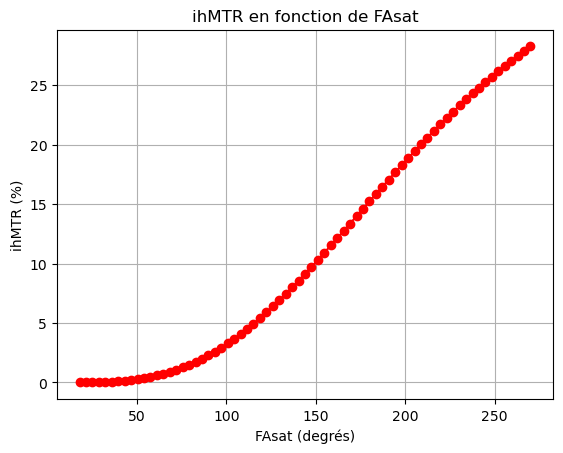

In [9]:
# Tracer ihMTR en fonction de B1rel
plt.plot(B1rel_range*flipAngle_nominal , ihMTR_values, marker='o', linestyle='-', color='r')
plt.xlabel('FAsat (degrés)')
plt.ylabel('ihMTR (%)')
plt.title('ihMTR en fonction de FAsat')
plt.grid(True)
plt.show()

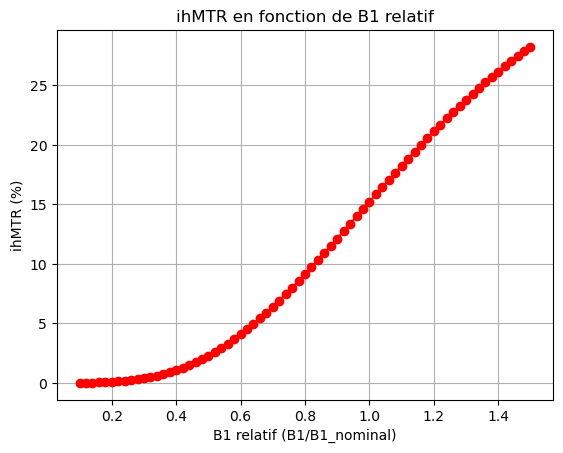

In [10]:
# Tracer ihMTR en fonction de B1rel
plt.plot(B1rel_range, ihMTR_values, marker='o', linestyle='-', color='r')
plt.xlabel('B1 relatif (B1/B1_nominal)')
plt.ylabel('ihMTR (%)')
plt.title('ihMTR en fonction de B1 relatif')
plt.grid(True)
plt.show()


In [11]:
print(ihMTR_values)

[0.005242599380614515, 0.010793512601953293, 0.01982842217027631, 0.03350018468123889, 0.05307725378004269, 0.07992029459206279, 0.1154575559847278, 0.16115955874987287, 0.2185136505454074, 0.2889989554904042, 0.37406220933820067, 0.4750949225110108, 0.5934122553398724, 0.7302339254801129, 0.8866673991536789, 1.0636935482985688, 1.2621548872710184, 1.482746437427268, 1.7260092075255389, 1.9923262236021557, 2.2819209950874786, 2.594858264450053, 2.9310468564953633, 3.2902444197580967, 3.6720638366509157, 4.075981069859512, 4.501344209823179, 4.94738349087328, 5.413222050881183, 5.897887220475858, 6.4003221418849305, 6.91939753363043, 7.453923435015603, 8.002660782735774, 8.56433269062758, 9.137635322176706, 9.721248263255553, 10.313844319809542, 10.914098681219343, 11.520697405001657, 12.132345192173076, 12.747772434820961, 13.365741528575168, 13.985052452216982, 14.604547625226399, 15.22311606127576, 15.839696841858931, 16.453281939297515, 17.062918422556077, 17.667710082504247, 18.266